In [23]:
import numpy as np
import torch
from os.path import join

In [24]:
data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'
data = np.load(join(data_path, 'data.npz'))
gene_sc = torch.tensor(data['arr_0'], dtype=torch.float32, device='cuda:0').squeeze(0)
gene_st = torch.tensor(data['arr_1'], dtype=torch.float32, device='cuda:0').squeeze(0)
# 标准化数据
# gene_sc = (gene_sc - gene_sc.mean(dim=0)) / gene_sc.std(dim=0)
# gene_st = (gene_st - gene_st.mean(dim=0)) / gene_st.std(dim=0)


In [25]:
print(gene_sc.shape)
print(gene_st.shape)

torch.Size([1289, 6025])
torch.Size([3366, 6025])


In [26]:
# import sim_tangram.train_tangram as tg_cca
# # tangram
# cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
#     [gene_sc[10:50]],
#     [gene_st[10:50]],
#     num_epochs=500,
#     print_interval=1,
#     lambda_g1=1,
#     lambda_g2=1,
# )

**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


  1%|          | 6/500 [00:00<00:09, 54.45it/s]

100%|██████████| 500/500 [00:10<00:00, 48.62it/s]


Epoch 500: Loss -1.415634036064148
[[ 0.43464196  0.10546076  0.22844686 ...  1.4000831   1.5986384
   1.6101958 ]
 [ 1.2835585   1.3111007   1.3179965  ...  1.9340477   1.4359865
   1.3831488 ]
 [ 1.1125393   1.0770786   1.099893   ...  1.5916098   1.0401722
   1.128475  ]
 ...
 [ 2.3687322   2.3902078   2.3972495  ... -2.7054136   0.76601374
   0.92659765]
 [ 2.462157    2.4659133   2.4728308  ...  2.0973394   1.3684721
   1.5407853 ]
 [ 2.2349129   2.2294412   2.2280045  ... -2.4466095  -0.4033273
   0.2956997 ]]


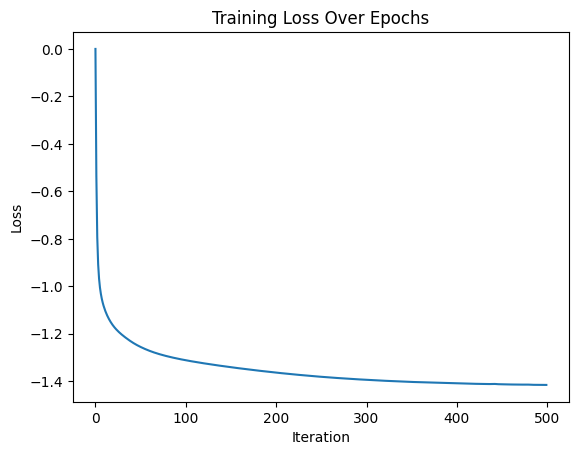

In [27]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc],
    [gene_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [55]:
sim2 = cos_sim_tg.copy()
prob = np.exp(sim2) / np.sum(np.exp(sim2), axis=1, keepdims=True)
maxprob = prob.max(axis=1)
mask = maxprob < 0.0009
first_hot = np.zeros_like(sim2[0])
first_hot[0] = 1
sim2[mask] = first_hot
# print(maxprob.min())
# print(maxprob.max())

In [56]:
torch.save(torch.tensor(cos_sim_tg, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg.pt')
torch.save(torch.tensor(sim2, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg2.pt')

# torch.save(torch.tensor(cca_tg_sim, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cca_tg.pt')

In [7]:
# 对每一行应用softmax转换为概率分布
tg = torch.tensor(cos_sim_tg, dtype=torch.float32)
tg_norm = tg / tg.sum(dim=1, keepdim=True)

In [12]:
torch.argmax(tg_norm, dim=1).shape

torch.Size([1289])